# 02 — Preparación del Dataset Combinado para Cumplimiento de EPP

Este notebook prepara un dataset combinado en formato YOLOv8 para entrenar el modelo final del sistema de cumplimiento de normas de seguridad en obras.

Se combinan distintas fuentes:

1. Safety Helmet Detection Dataset.
2. PPE Detection Dataset.
3. Worker Detection Dataset.
4. SHWD como posible refuerzo posterior.

La salida final será un archivo:

`ppe_combined_dataset.zip`

Este archivo se descargará localmente y luego será usado en otro notebook con GPU para entrenar el modelo final.

## 1. Instalación de librerías

Se instalan las librerías necesarias para descargar datasets desde Roboflow, manipular etiquetas YOLO y generar el dataset combinado.

In [ ]:
!pip install roboflow pyyaml tqdm opencv-python matplotlib pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 119.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


## 2. Configuración inicial

Se crean las carpetas temporales del proyecto. Al final del notebook, el dataset combinado se comprimirá en un archivo `.zip` para descargarlo localmente.

In [ ]:
from pathlib import Path
import os
import shutil
import yaml
from tqdm import tqdm
from collections import Counter
import random
import cv2
import matplotlib.pyplot as plt

# Carpeta temporal principal del proyecto en Colab.
BASE_DIR = Path("/content/ppe_combined_project")

# Carpeta para datasets originales descargados.
RAW_DATA_DIR = BASE_DIR / "raw_datasets"

# Carpeta para el dataset final combinado.
COMBINED_DATASET_DIR = BASE_DIR / "ppe_combined_dataset"

# Si existe una versión anterior, la eliminamos para evitar mezcla de archivos.
if BASE_DIR.exists():
    shutil.rmtree(BASE_DIR)

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
COMBINED_DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Crear estructura YOLO final.
for split in ["train", "valid", "test"]:
    (COMBINED_DATASET_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (COMBINED_DATASET_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

print("Carpeta base:", BASE_DIR)
print("Datasets originales:", RAW_DATA_DIR)
print("Dataset combinado:", COMBINED_DATASET_DIR)

Carpeta base: /content/ppe_combined_project
Datasets originales: /content/ppe_combined_project/raw_datasets
Dataset combinado: /content/ppe_combined_project/ppe_combined_dataset


## 3. Definición de clases finales

Se define el espacio común de clases para combinar datasets con nombres distintos.

In [ ]:
# Clases finales del modelo YOLO combinado.
FINAL_CLASSES = {
    0: "person",
    1: "helmet",
    2: "no_helmet",
    3: "vest",
    4: "no_vest",
    5: "gloves",
    6: "goggles",
    7: "boots"
}

# Diccionario inverso: nombre -> id
FINAL_CLASS_TO_ID = {name: idx for idx, name in FINAL_CLASSES.items()}

print("Clases finales:")
for idx, name in FINAL_CLASSES.items():
    print(idx, name)

Clases finales:
0 person
1 helmet
2 no_helmet
3 vest
4 no_vest
5 gloves
6 goggles
7 boots


## 4. Configuración de Roboflow

Se configura la API de Roboflow para descargar datasets en formato YOLOv8.

Importante: no compartir públicamente la API key.

In [ ]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = "lxN0r144V4FwUNthKDVY"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

print("Roboflow configurado correctamente.")

Roboflow configurado correctamente.


## 5. Descarga del Safety Helmet Detection Dataset

Se descarga el dataset principal de cascos desde Roboflow en formato YOLOv8.

Este dataset aporta las clases:
- `head`, que será remapeada como `no_helmet`
- `helmet`
- `person`

In [ ]:
# Descargar Safety Helmet Detection Dataset desde Roboflow.

project_helmet = rf.workspace("marina-wgvsb").project("safety-helmet-detection-apiwd")
version_helmet = project_helmet.version(2)

dataset_helmet = version_helmet.download(
    "yolov8",
    location=str(RAW_DATA_DIR / "safety_helmet")
)

helmet_dataset_path = Path(dataset_helmet.location)

print("Safety Helmet Dataset descargado en:", helmet_dataset_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/ppe_combined_project/raw_datasets/safety_helmet in yolov8:: 100%|██████████| 28140/28140 [00:09<00:00, 3078.42it/s]


Safety Helmet Dataset descargado en: /content/ppe_combined_project/raw_datasets/safety_helmet


## 6. Revisión del Safety Helmet Detection Dataset

Se revisan las clases y el número de anotaciones para confirmar el mapeo antes de combinarlo con otros datasets.

In [ ]:
# Leer el archivo data.yaml del Safety Helmet Dataset.

helmet_yaml_path = helmet_dataset_path / "data.yaml"

with open(helmet_yaml_path, "r") as f:
    helmet_yaml = yaml.safe_load(f)

print("Rutas del dataset:")
print("Train:", helmet_yaml.get("train"))
print("Valid:", helmet_yaml.get("val"))
print("Test:", helmet_yaml.get("test"))

print("\nClases originales:")
for idx, name in enumerate(helmet_yaml["names"]):
    print(idx, name)

Rutas del dataset:
Train: ../train/images
Valid: ../valid/images
Test: ../test/images

Clases originales:
0 head
1 helmet
2 person


In [ ]:
def count_yolo_labels(dataset_path, class_names):
    """
    Cuenta anotaciones YOLO por clase en los splits train, valid y test.
    """
    counts = Counter()

    for split in ["train", "valid", "test"]:
        labels_dir = dataset_path / split / "labels"

        if not labels_dir.exists():
            continue

        for label_file in labels_dir.glob("*.txt"):
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        counts[class_id] += 1

    for class_id, class_name in enumerate(class_names):
        print(f"Clase {class_id}: {class_name} -> {counts[class_id]} anotaciones")

    return counts


print("Conteo de anotaciones del Safety Helmet Dataset:\n")
helmet_counts = count_yolo_labels(helmet_dataset_path, helmet_yaml["names"])

Conteo de anotaciones del Safety Helmet Dataset:

Clase 0: head -> 16426 anotaciones
Clase 1: helmet -> 52459 anotaciones
Clase 2: person -> 2072 anotaciones


## 7. Función para agregar datasets al combinado

Se define una función general para copiar imágenes y etiquetas desde un dataset fuente hacia el dataset combinado, remapeando las clases originales al espacio común de clases finales.

In [ ]:
def add_dataset_to_combined(source_dataset_path, source_names, class_mapping, dataset_prefix):
    """
    Agrega un dataset YOLO al dataset combinado.

    Parámetros:
    - source_dataset_path: ruta del dataset fuente.
    - source_names: lista de clases originales del dataset fuente.
    - class_mapping: diccionario que mapea clases originales a clases finales.
      Ejemplo:
      {
          "head": "no_helmet",
          "helmet": "helmet",
          "person": "person"
      }
    - dataset_prefix: prefijo para evitar nombres repetidos de imágenes.
    """

    summary = {}

    for split in ["train", "valid", "test"]:
        src_images_dir = source_dataset_path / split / "images"
        src_labels_dir = source_dataset_path / split / "labels"

        dst_images_dir = COMBINED_DATASET_DIR / split / "images"
        dst_labels_dir = COMBINED_DATASET_DIR / split / "labels"

        if not src_images_dir.exists():
            print(f"No existe carpeta de imágenes para {dataset_prefix} - {split}")
            continue

        image_files = list(src_images_dir.glob("*"))

        copied_images = 0
        total_boxes = 0
        kept_boxes = 0

        for image_path in tqdm(image_files, desc=f"Agregando {dataset_prefix} {split}"):
            label_path = src_labels_dir / (image_path.stem + ".txt")

            new_label_lines = []

            if label_path.exists():
                with open(label_path, "r") as f:
                    lines = f.readlines()

                for line in lines:
                    parts = line.strip().split()

                    if len(parts) < 5:
                        continue

                    old_class_id = int(parts[0])
                    old_class_name = source_names[old_class_id]

                    total_boxes += 1

                    # Si la clase original no está en el mapeo, se ignora.
                    if old_class_name not in class_mapping:
                        continue

                    final_class_name = class_mapping[old_class_name]

                    # Si el mapeo dice None, también se ignora.
                    if final_class_name is None:
                        continue

                    final_class_id = FINAL_CLASS_TO_ID[final_class_name]

                    new_line = " ".join([str(final_class_id)] + parts[1:])
                    new_label_lines.append(new_line)
                    kept_boxes += 1

            # Crear nombre único para evitar sobreescrituras.
            new_image_name = f"{dataset_prefix}_{split}_{image_path.name}"
            new_label_name = f"{Path(new_image_name).stem}.txt"

            shutil.copy2(image_path, dst_images_dir / new_image_name)

            with open(dst_labels_dir / new_label_name, "w") as f:
                if len(new_label_lines) > 0:
                    f.write("\n".join(new_label_lines) + "\n")

            copied_images += 1

        summary[split] = {
            "images": copied_images,
            "total_boxes": total_boxes,
            "kept_boxes": kept_boxes
        }

    return summary

## 8. Incorporación del Safety Helmet Detection Dataset

Se incorpora el Safety Helmet Detection Dataset al dataset combinado usando el siguiente mapeo:

- `head` → `no_helmet`
- `helmet` → `helmet`
- `person` → `person`

In [ ]:
helmet_class_mapping = {
    "head": "no_helmet",
    "helmet": "helmet",
    "person": "person"
}

helmet_summary = add_dataset_to_combined(
    source_dataset_path=helmet_dataset_path,
    source_names=helmet_yaml["names"],
    class_mapping=helmet_class_mapping,
    dataset_prefix="safetyhelmet"
)

print("Resumen Safety Helmet agregado al combinado:")
for split, info in helmet_summary.items():
    print(split, info)

Agregando safetyhelmet test: 100%|██████████| 616/616 [00:00<00:00, 1755.37it/s]

Resumen Safety Helmet agregado al combinado:
train {'images': 12250, 'total_boxes': 61729, 'kept_boxes': 61729}
valid {'images': 1198, 'total_boxes': 6063, 'kept_boxes': 6063}
test {'images': 616, 'total_boxes': 3165, 'kept_boxes': 3165}


## 9. Descarga del PPE Detection Dataset

Se descarga el PPE Detection Dataset desde Roboflow Universe.  
Este dataset complementa al anterior incorporando clases adicionales de EPP, especialmente:

- `vest`
- `no-vest`
- `gloves`
- `goggles`
- `boots`
- `helmet`
- `no-helmet`

In [ ]:
# Descargar PPE Detection Dataset desde Roboflow.

project_ppe = rf.workspace("testcasque").project("ppe-detection-qlq3d")
version_ppe = project_ppe.version(1)

dataset_ppe = version_ppe.download(
    "yolov8",
    location=str(RAW_DATA_DIR / "ppe_detection")
)

ppe_dataset_path = Path(dataset_ppe.location)

print("PPE Detection Dataset descargado en:", ppe_dataset_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/ppe_combined_project/raw_datasets/ppe_detection in yolov8:: 100%|██████████| 10292/10292 [00:02<00:00, 5073.57it/s]


PPE Detection Dataset descargado en: /content/ppe_combined_project/raw_datasets/ppe_detection


## 10. Revisión del PPE Detection Dataset

Se revisan las clases originales del PPE Detection Dataset antes de incorporarlo al dataset combinado.

In [ ]:
# Leer data.yaml del PPE Dataset.

ppe_yaml_path = ppe_dataset_path / "data.yaml"

with open(ppe_yaml_path, "r") as f:
    ppe_yaml = yaml.safe_load(f)

print("Rutas del dataset:")
print("Train:", ppe_yaml.get("train"))
print("Valid:", ppe_yaml.get("val"))
print("Test:", ppe_yaml.get("test"))

print("\nClases originales PPE:")
for idx, name in enumerate(ppe_yaml["names"]):
    print(idx, name)

Rutas del dataset:
Train: ../train/images
Valid: ../valid/images
Test: ../test/images

Clases originales PPE:
0 boots
1 gloves
2 goggles
3 helmet
4 no-boots
5 no-gloves
6 no-goggles
7 no-helmet
8 no-vest
9 vest


In [ ]:
print("Conteo de anotaciones del PPE Dataset:\n")
ppe_counts = count_yolo_labels(ppe_dataset_path, ppe_yaml["names"])

Conteo de anotaciones del PPE Dataset:

Clase 0: boots -> 4601 anotaciones
Clase 1: gloves -> 1549 anotaciones
Clase 2: goggles -> 588 anotaciones
Clase 3: helmet -> 5893 anotaciones
Clase 4: no-boots -> 163 anotaciones
Clase 5: no-gloves -> 334 anotaciones
Clase 6: no-goggles -> 843 anotaciones
Clase 7: no-helmet -> 598 anotaciones
Clase 8: no-vest -> 1175 anotaciones
Clase 9: vest -> 5841 anotaciones


## 11. Incorporación del PPE Detection Dataset

Se incorpora el PPE Detection Dataset al dataset combinado.

Mapeo utilizado:

- `helmet` → `helmet`
- `no-helmet` → `no_helmet`
- `vest` → `vest`
- `no-vest` → `no_vest`
- `gloves` → `gloves`
- `goggles` → `goggles`
- `boots` → `boots`

Las clases `no-boots`, `no-gloves` y `no-goggles` se ignoran, ya que el sistema principal se enfoca en cumplimiento de casco y chaleco.

In [ ]:
ppe_class_mapping = {
    "helmet": "helmet",
    "no-helmet": "no_helmet",
    "vest": "vest",
    "no-vest": "no_vest",
    "gloves": "gloves",
    "goggles": "goggles",
    "boots": "boots",

    # Clases ignoradas para simplificar el sistema de cumplimiento principal.
    "no-boots": None,
    "no-gloves": None,
    "no-goggles": None
}

ppe_summary = add_dataset_to_combined(
    source_dataset_path=ppe_dataset_path,
    source_names=ppe_yaml["names"],
    class_mapping=ppe_class_mapping,
    dataset_prefix="ppe"
)

print("Resumen PPE Detection agregado al combinado:")
for split, info in ppe_summary.items():
    print(split, info)

Agregando ppe test: 100%|██████████| 517/517 [00:00<00:00, 2008.50it/s]

Resumen PPE Detection agregado al combinado:
train {'images': 3597, 'total_boxes': 15205, 'kept_boxes': 14245}
valid {'images': 1026, 'total_boxes': 4307, 'kept_boxes': 4065}
test {'images': 517, 'total_boxes': 2073, 'kept_boxes': 1935}


## 12. Descarga del Worker Detection Dataset

Se descarga un dataset auxiliar de detección de trabajadores/personas.  
Este dataset se incorpora para reforzar la clase `person`, ya que en el modelo base esta clase presentó menor rendimiento.

Clases esperadas:
- `person`
- `worker`
- `null`

Para el dataset combinado se usará el siguiente criterio:

- `person` → `person`
- `worker` → `person`
- `null` → ignorar

In [ ]:
# Descargar Worker Detection Dataset desde Roboflow.

project_worker = rf.workspace("inzynierka-fcqsu").project("worker-detection-wh7fp")
version_worker = project_worker.version(3)

dataset_worker = version_worker.download(
    "yolov8",
    location=str(RAW_DATA_DIR / "worker_detection")
)

worker_dataset_path = Path(dataset_worker.location)

print("Worker Detection Dataset descargado en:", worker_dataset_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/ppe_combined_project/raw_datasets/worker_detection in yolov8:: 100%|██████████| 3443/3443 [00:00<00:00, 3964.50it/s]

Worker Detection Dataset descargado en: /content/ppe_combined_project/raw_datasets/worker_detection


## 13. Revisión del Worker Detection Dataset

Se revisan las clases originales y la cantidad de anotaciones antes de incorporarlo al dataset combinado.

In [ ]:
# Leer data.yaml del Worker Detection Dataset.

worker_yaml_path = worker_dataset_path / "data.yaml"

with open(worker_yaml_path, "r") as f:
    worker_yaml = yaml.safe_load(f)

print("Rutas del dataset:")
print("Train:", worker_yaml.get("train"))
print("Valid:", worker_yaml.get("val"))
print("Test:", worker_yaml.get("test"))

print("\nClases originales Worker:")
for idx, name in enumerate(worker_yaml["names"]):
    print(idx, name)

Rutas del dataset:
Train: ../train/images
Valid: ../valid/images
Test: ../test/images

Clases originales Worker:
0 person
1 worker


In [ ]:
print("Conteo de anotaciones del Worker Detection Dataset:\n")
worker_counts = count_yolo_labels(worker_dataset_path, worker_yaml["names"])

Conteo de anotaciones del Worker Detection Dataset:

Clase 0: person -> 2225 anotaciones
Clase 1: worker -> 2031 anotaciones


## 14. Incorporación del Worker Detection Dataset

Se incorpora el Worker Detection Dataset al dataset combinado para reforzar la detección de cuerpos completos.

Mapeo utilizado:

- `person` → `person`
- `worker` → `person`

Ambas clases se unifican porque el verificador de cumplimiento necesita detectar trabajadores/personas como una sola clase base.

In [ ]:
worker_class_mapping = {
    "person": "person",
    "worker": "person"
}

worker_summary = add_dataset_to_combined(
    source_dataset_path=worker_dataset_path,
    source_names=worker_yaml["names"],
    class_mapping=worker_class_mapping,
    dataset_prefix="worker"
)

print("Resumen Worker Detection agregado al combinado:")
for split, info in worker_summary.items():
    print(split, info)

Agregando worker test: 100%|██████████| 172/172 [00:00<00:00, 2381.41it/s]

Resumen Worker Detection agregado al combinado:
train {'images': 1205, 'total_boxes': 3023, 'kept_boxes': 3023}
valid {'images': 342, 'total_boxes': 826, 'kept_boxes': 826}
test {'images': 172, 'total_boxes': 407, 'kept_boxes': 407}


## 15. Conteo final de anotaciones del dataset combinado

Se cuentan todas las anotaciones del dataset combinado para verificar la distribución final de clases.

In [ ]:
def count_combined_dataset():
    """
    Cuenta anotaciones por clase en el dataset combinado.
    """
    combined_counts = Counter()

    for split in ["train", "valid", "test"]:
        labels_dir = COMBINED_DATASET_DIR / split / "labels"

        for label_file in labels_dir.glob("*.txt"):
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()

                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        combined_counts[class_id] += 1

    print("Conteo total de anotaciones del dataset combinado:\n")

    for class_id, class_name in FINAL_CLASSES.items():
        print(f"Clase {class_id}: {class_name} -> {combined_counts[class_id]} anotaciones")

    return combined_counts


combined_counts = count_combined_dataset()

Conteo total de anotaciones del dataset combinado:

Clase 0: person -> 6328 anotaciones
Clase 1: helmet -> 58352 anotaciones
Clase 2: no_helmet -> 17024 anotaciones
Clase 3: vest -> 5841 anotaciones
Clase 4: no_vest -> 1175 anotaciones
Clase 5: gloves -> 1549 anotaciones
Clase 6: goggles -> 588 anotaciones
Clase 7: boots -> 4601 anotaciones


In [ ]:
print("Conteo de imágenes del dataset combinado:\n")

for split in ["train", "valid", "test"]:
    images_dir = COMBINED_DATASET_DIR / split / "images"
    labels_dir = COMBINED_DATASET_DIR / split / "labels"

    num_images = len(list(images_dir.glob("*")))
    num_labels = len(list(labels_dir.glob("*.txt")))

    print(f"{split}: {num_images} imágenes, {num_labels} archivos de etiquetas")

Conteo de imágenes del dataset combinado:

train: 17052 imágenes, 17052 archivos de etiquetas
valid: 2566 imágenes, 2566 archivos de etiquetas
test: 1305 imágenes, 1305 archivos de etiquetas


## 16. Descarga del dataset SHWD

Se descarga el Safety Helmet Wearing Dataset desde Google Drive.  
Este dataset está en formato Pascal VOC y contiene dos clases principales:

- `hat`: cabeza/persona con casco.
- `person`: cabeza/persona sin casco.

Para el dataset combinado se usará el siguiente mapeo:

- `hat` → `helmet`
- `person` → `no_helmet`

In [ ]:
!pip install gdown

In [ ]:
import gdown
from pathlib import Path

SHWD_DIR = RAW_DATA_DIR / "shwd"
SHWD_DIR.mkdir(parents=True, exist_ok=True)

shwd_file_id = "1qWm7rrwvjAWs1slymbrLaCf7Q-wnGLEX"
shwd_zip_path = SHWD_DIR / "SHWD.zip"

gdown.download(
    id=shwd_file_id,
    output=str(shwd_zip_path),
    quiet=False
)

print("Archivo descargado en:", shwd_zip_path)
print("Existe:", shwd_zip_path.exists())
print("Tamaño MB:", shwd_zip_path.stat().st_size / (1024 * 1024) if shwd_zip_path.exists() else "No existe")

Downloading...
From (original): https://drive.google.com/uc?id=1qWm7rrwvjAWs1slymbrLaCf7Q-wnGLEX
From (redirected): https://drive.google.com/uc?id=1qWm7rrwvjAWs1slymbrLaCf7Q-wnGLEX&confirm=t&uuid=7009936e-7c59-421f-8c94-b68bfdde58ba
To: /content/ppe_combined_project/raw_datasets/shwd/SHWD.zip
100%|██████████| 1.12G/1.12G [00:13<00:00, 80.4MB/s]

Archivo descargado en: /content/ppe_combined_project/raw_datasets/shwd/SHWD.zip
Existe: True
Tamaño MB: 1066.1797876358032


## 16C. Descompresión del dataset SHWD

Se descomprime el archivo ZIP descargado desde Google Drive para revisar su estructura interna.

In [ ]:
import zipfile

shwd_extract_dir = SHWD_DIR / "extracted"
shwd_extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(shwd_zip_path, "r") as zip_ref:
    zip_ref.extractall(shwd_extract_dir)

print("SHWD descomprimido en:", shwd_extract_dir)

# Mostrar carpetas/archivos principales
print("\nContenido principal:")
for item in shwd_extract_dir.iterdir():
    print(item)

SHWD descomprimido en: /content/ppe_combined_project/raw_datasets/shwd/extracted

Contenido principal:
/content/ppe_combined_project/raw_datasets/shwd/extracted/VOC2028


In [ ]:
# Buscar carpetas típicas Pascal VOC dentro de SHWD.
for folder_name in ["Annotations", "JPEGImages", "ImageSets"]:
    matches = list(shwd_extract_dir.rglob(folder_name))
    print(f"\nCarpetas encontradas para {folder_name}:")
    for m in matches:
        print(m)


Carpetas encontradas para Annotations:
/content/ppe_combined_project/raw_datasets/shwd/extracted/VOC2028/Annotations

Carpetas encontradas para JPEGImages:
/content/ppe_combined_project/raw_datasets/shwd/extracted/VOC2028/JPEGImages

Carpetas encontradas para ImageSets:
/content/ppe_combined_project/raw_datasets/shwd/extracted/VOC2028/ImageSets


## 16E. Revisión de anotaciones XML de SHWD

Antes de convertir SHWD a formato YOLO, se revisan algunos archivos XML para confirmar los nombres reales de las clases.

In [ ]:
import xml.etree.ElementTree as ET
from collections import Counter

# Rutas Pascal VOC de SHWD
shwd_voc_dir = shwd_extract_dir / "VOC2028"
shwd_annotations_dir = shwd_voc_dir / "Annotations"
shwd_images_dir = shwd_voc_dir / "JPEGImages"
shwd_imagesets_dir = shwd_voc_dir / "ImageSets"

print("Annotations:", shwd_annotations_dir)
print("JPEGImages:", shwd_images_dir)
print("ImageSets:", shwd_imagesets_dir)

# Contar clases en los XML
shwd_xml_files = list(shwd_annotations_dir.glob("*.xml"))
print("Cantidad de XML:", len(shwd_xml_files))

shwd_class_counter = Counter()

for xml_file in shwd_xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip()
        shwd_class_counter[class_name] += 1

print("\nClases encontradas en SHWD:")
for class_name, count in shwd_class_counter.items():
    print(class_name, "->", count)

Annotations: /content/ppe_combined_project/raw_datasets/shwd/extracted/VOC2028/Annotations
JPEGImages: /content/ppe_combined_project/raw_datasets/shwd/extracted/VOC2028/JPEGImages
ImageSets: /content/ppe_combined_project/raw_datasets/shwd/extracted/VOC2028/ImageSets
Cantidad de XML: 7581

Clases encontradas en SHWD:
person -> 111514
hat -> 9044
dog -> 3


## 16F. Conversión de SHWD a formato YOLO e incorporación al dataset combinado

SHWD está anotado en formato Pascal VOC/XML.  
Se convierte cada bounding box al formato YOLO:

`class_id x_center y_center width height`

Mapeo aplicado:

- `hat` → `helmet`
- `person` → `no_helmet`
- `dog` → ignorar

La clase `person` en SHWD representa una cabeza/persona sin casco, por lo que se interpreta como `no_helmet`.

In [ ]:
def voc_box_to_yolo(size, box):
    """
    Convierte una caja Pascal VOC a formato YOLO normalizado.

    size: (width, height)
    box: (xmin, ymin, xmax, ymax)
    """
    img_w, img_h = size
    xmin, ymin, xmax, ymax = box

    # Asegurar límites válidos
    xmin = max(0, xmin)
    ymin = max(0, ymin)
    xmax = min(img_w, xmax)
    ymax = min(img_h, ymax)

    box_w = xmax - xmin
    box_h = ymax - ymin

    if box_w <= 0 or box_h <= 0:
        return None

    x_center = xmin + box_w / 2
    y_center = ymin + box_h / 2

    return (
        x_center / img_w,
        y_center / img_h,
        box_w / img_w,
        box_h / img_h
    )


shwd_class_mapping = {
    "hat": "helmet",
    "person": "no_helmet",
    "dog": None
}

In [ ]:
# Usar los splits oficiales de SHWD desde VOC2028/ImageSets/Main

shwd_main_dir = shwd_imagesets_dir / "Main"

def read_voc_split(split_file):
    """
    Lee un archivo de split Pascal VOC.
    Cada línea contiene el ID de una imagen sin extensión.
    """
    ids = []
    with open(split_file, "r") as f:
        for line in f:
            image_id = line.strip()
            if image_id:
                ids.append(image_id)
    return ids

shwd_train_ids = read_voc_split(shwd_main_dir / "train.txt")
shwd_valid_ids = read_voc_split(shwd_main_dir / "val.txt")
shwd_test_ids = read_voc_split(shwd_main_dir / "test.txt")

shwd_split_ids = {
    "train": shwd_train_ids,
    "valid": shwd_valid_ids,
    "test": shwd_test_ids
}

print("Split oficial SHWD:")
for split, ids in shwd_split_ids.items():
    print(split, len(ids))

Split oficial SHWD:
train 5457
valid 607
test 1517


In [ ]:
def add_shwd_to_combined_from_official_split():
    """
    Convierte SHWD desde Pascal VOC/XML a YOLO y lo agrega al dataset combinado
    usando los splits oficiales train/val/test del dataset.
    """

    summary = {}

    for split, image_ids in shwd_split_ids.items():
        dst_images_dir = COMBINED_DATASET_DIR / split / "images"
        dst_labels_dir = COMBINED_DATASET_DIR / split / "labels"

        copied_images = 0
        total_boxes = 0
        kept_boxes = 0
        skipped_images = 0
        skipped_xml = 0

        for image_id in tqdm(image_ids, desc=f"Agregando SHWD {split}"):
            xml_file = shwd_annotations_dir / f"{image_id}.xml"

            if not xml_file.exists():
                skipped_xml += 1
                continue

            tree = ET.parse(xml_file)
            root = tree.getroot()

            filename_node = root.find("filename")
            size_node = root.find("size")

            if filename_node is None or size_node is None:
                skipped_images += 1
                continue

            filename = filename_node.text.strip()

            img_w = int(size_node.find("width").text)
            img_h = int(size_node.find("height").text)

            image_path = shwd_images_dir / filename

            # Si no existe exactamente, buscar por ID con cualquier extensión.
            if not image_path.exists():
                candidates = list(shwd_images_dir.glob(image_id + ".*"))
                if len(candidates) > 0:
                    image_path = candidates[0]
                else:
                    skipped_images += 1
                    continue

            new_label_lines = []

            for obj in root.findall("object"):
                class_name = obj.find("name").text.strip()
                total_boxes += 1

                if class_name not in shwd_class_mapping:
                    continue

                final_class_name = shwd_class_mapping[class_name]

                if final_class_name is None:
                    continue

                final_class_id = FINAL_CLASS_TO_ID[final_class_name]

                bndbox = obj.find("bndbox")
                xmin = float(bndbox.find("xmin").text)
                ymin = float(bndbox.find("ymin").text)
                xmax = float(bndbox.find("xmax").text)
                ymax = float(bndbox.find("ymax").text)

                yolo_box = voc_box_to_yolo((img_w, img_h), (xmin, ymin, xmax, ymax))

                if yolo_box is None:
                    continue

                x_center, y_center, box_w, box_h = yolo_box

                new_line = f"{final_class_id} {x_center:.6f} {y_center:.6f} {box_w:.6f} {box_h:.6f}"
                new_label_lines.append(new_line)
                kept_boxes += 1

            new_image_name = f"shwd_{split}_{image_path.name}"
            new_label_name = f"{Path(new_image_name).stem}.txt"

            shutil.copy2(image_path, dst_images_dir / new_image_name)

            with open(dst_labels_dir / new_label_name, "w") as f:
                if len(new_label_lines) > 0:
                    f.write("\n".join(new_label_lines) + "\n")

            copied_images += 1

        summary[split] = {
            "images": copied_images,
            "total_boxes": total_boxes,
            "kept_boxes": kept_boxes,
            "skipped_images": skipped_images,
            "skipped_xml": skipped_xml
        }

    return summary


shwd_summary = add_shwd_to_combined_from_official_split()

print("Resumen SHWD agregado al combinado:")
for split, info in shwd_summary.items():
    print(split, info)

Agregando SHWD test: 100%|██████████| 1517/1517 [00:08<00:00, 174.63it/s]

Resumen SHWD agregado al combinado:
train {'images': 5457, 'total_boxes': 86200, 'kept_boxes': 86197, 'skipped_images': 0, 'skipped_xml': 0}
valid {'images': 607, 'total_boxes': 9925, 'kept_boxes': 9925, 'skipped_images': 0, 'skipped_xml': 0}
test {'images': 1517, 'total_boxes': 24436, 'kept_boxes': 24436, 'skipped_images': 0, 'skipped_xml': 0}


## 17. Conteo final actualizado del dataset combinado

Después de incorporar SHWD, se recalcula la distribución total de clases del dataset combinado.

In [ ]:
combined_counts = count_combined_dataset()

Conteo total de anotaciones del dataset combinado:

Clase 0: person -> 6328 anotaciones
Clase 1: helmet -> 67396 anotaciones
Clase 2: no_helmet -> 128538 anotaciones
Clase 3: vest -> 5841 anotaciones
Clase 4: no_vest -> 1175 anotaciones
Clase 5: gloves -> 1549 anotaciones
Clase 6: goggles -> 588 anotaciones
Clase 7: boots -> 4601 anotaciones


In [ ]:
print("Conteo actualizado de imágenes del dataset combinado:\n")

for split in ["train", "valid", "test"]:
    images_dir = COMBINED_DATASET_DIR / split / "images"
    labels_dir = COMBINED_DATASET_DIR / split / "labels"

    num_images = len(list(images_dir.glob("*")))
    num_labels = len(list(labels_dir.glob("*.txt")))

    print(f"{split}: {num_images} imágenes, {num_labels} archivos de etiquetas")

Conteo actualizado de imágenes del dataset combinado:

train: 22509 imágenes, 22509 archivos de etiquetas
valid: 3173 imágenes, 3173 archivos de etiquetas
test: 2822 imágenes, 2822 archivos de etiquetas


## 18. Creación del archivo `data.yaml` final

Se crea el archivo `data.yaml` del dataset combinado. Este archivo será usado en el Notebook 3 para entrenar el modelo YOLOv8 final.

In [ ]:
combined_data_yaml = {
    "path": str(COMBINED_DATASET_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "names": FINAL_CLASSES
}

combined_data_yaml_path = COMBINED_DATASET_DIR / "data.yaml"

with open(combined_data_yaml_path, "w") as f:
    yaml.dump(combined_data_yaml, f, sort_keys=False)

print("data.yaml final creado en:", combined_data_yaml_path)
print("\nContenido del data.yaml:\n")

with open(combined_data_yaml_path, "r") as f:
    print(f.read())

data.yaml final creado en: /content/ppe_combined_project/ppe_combined_dataset/data.yaml

Contenido del data.yaml:

path: /content/ppe_combined_project/ppe_combined_dataset
train: train/images
val: valid/images
test: test/images
names:
  0: person
  1: helmet
  2: no_helmet
  3: vest
  4: no_vest
  5: gloves
  6: goggles
  7: boots



## 19. Visualización de ejemplos del dataset combinado

Se muestran algunas imágenes aleatorias del dataset combinado con sus bounding boxes para verificar que las clases fueron remapeadas correctamente.

Imágenes de entrenamiento combinadas: 22509


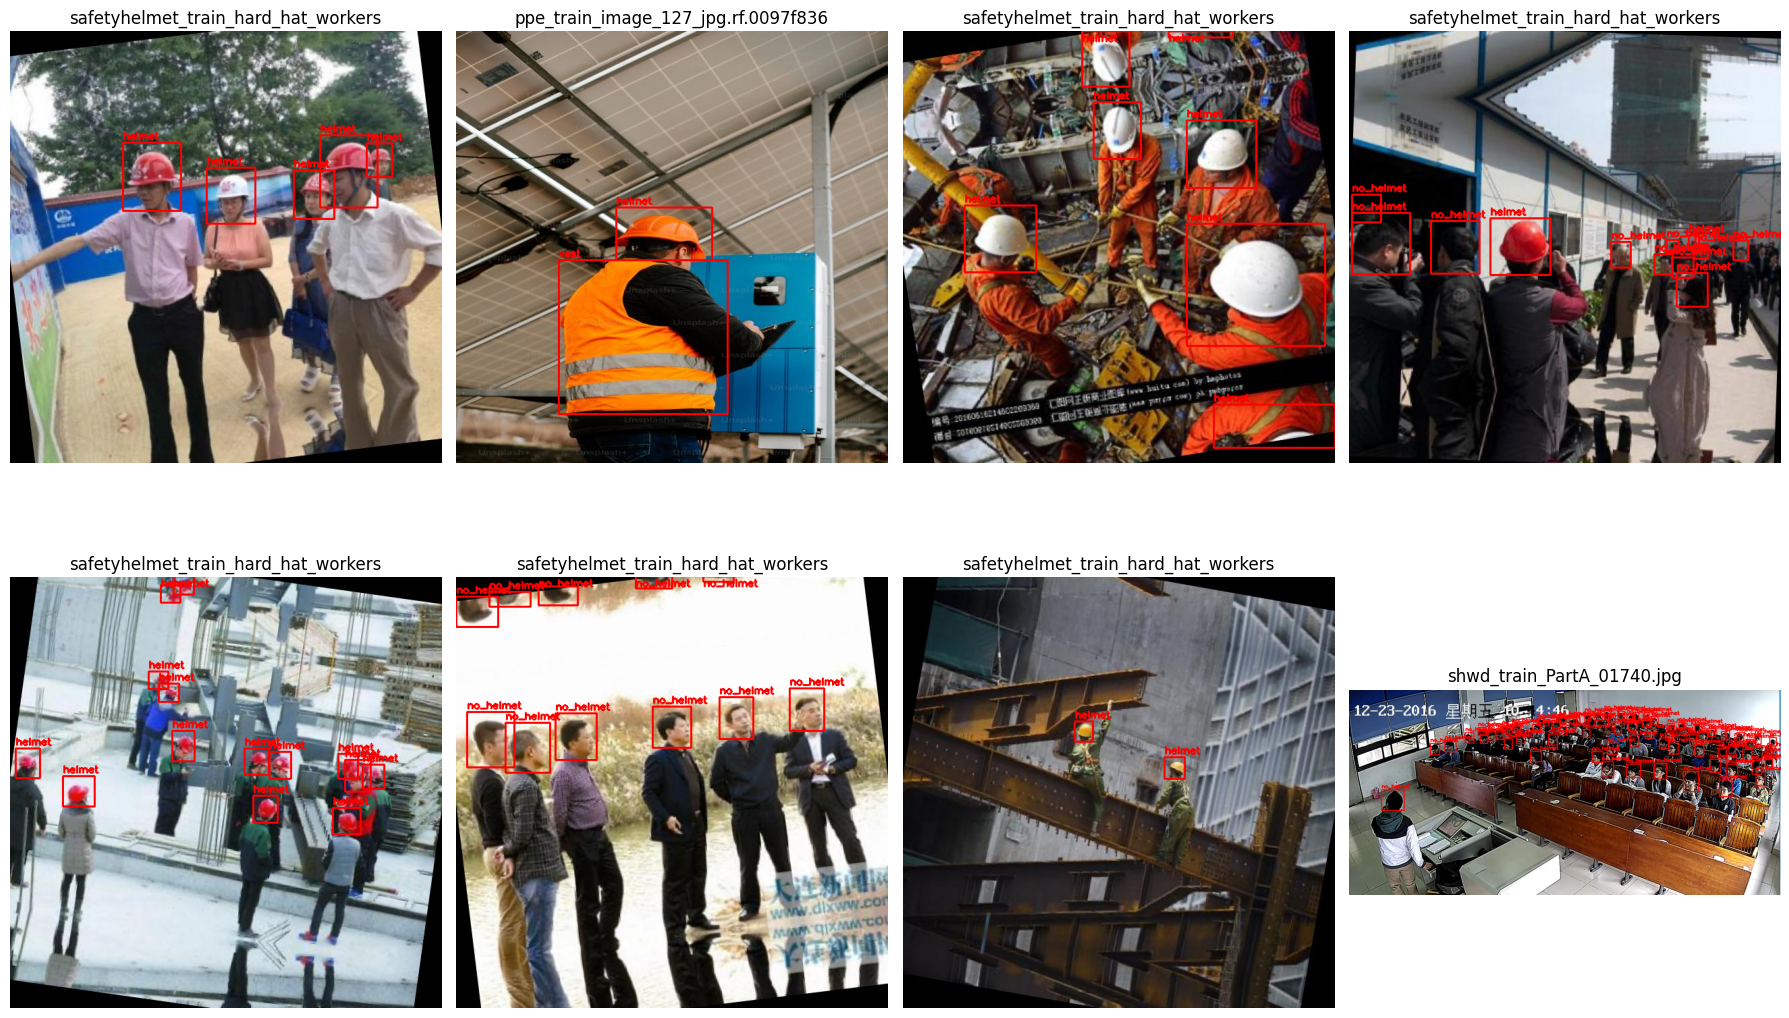

In [ ]:
def draw_yolo_boxes(image_path, label_path, class_names):
    """
    Dibuja cajas YOLO sobre una imagen.
    """
    image = cv2.imread(str(image_path))

    if image is None:
        return None

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) < 5:
                continue

            class_id = int(parts[0])
            x_center, y_center, box_w, box_h = map(float, parts[1:5])

            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)

            label = class_names[class_id]

            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(
                image,
                label,
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                2
            )

    return image


combined_class_names = [FINAL_CLASSES[i] for i in range(len(FINAL_CLASSES))]

combined_train_images_dir = COMBINED_DATASET_DIR / "train" / "images"
combined_train_labels_dir = COMBINED_DATASET_DIR / "train" / "labels"

combined_image_files = list(combined_train_images_dir.glob("*"))

print("Imágenes de entrenamiento combinadas:", len(combined_image_files))

sample_images = random.sample(combined_image_files, min(8, len(combined_image_files)))

plt.figure(figsize=(18, 12))

for i, image_path in enumerate(sample_images):
    label_path = combined_train_labels_dir / (image_path.stem + ".txt")
    image = draw_yolo_boxes(image_path, label_path, combined_class_names)

    if image is None:
        continue

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path.name[:35])

plt.tight_layout()
plt.show()

## 20. Compresión del dataset combinado

Se comprime el dataset combinado final en un archivo `.zip` para descargarlo localmente y usarlo posteriormente en otro notebook con GPU.

In [ ]:
# Comprimir el dataset combinado final en un archivo ZIP.

zip_output_path = BASE_DIR / "ppe_combined_dataset.zip"

# Si ya existe un ZIP anterior, se elimina.
if zip_output_path.exists():
    zip_output_path.unlink()

# Crear ZIP.
shutil.make_archive(
    base_name=str(zip_output_path).replace(".zip", ""),
    format="zip",
    root_dir=str(BASE_DIR),
    base_dir="ppe_combined_dataset"
)

print("ZIP creado en:", zip_output_path)
print("Existe:", zip_output_path.exists())
print("Tamaño GB:", zip_output_path.stat().st_size / (1024 ** 3))

ZIP creado en: /content/ppe_combined_project/ppe_combined_dataset.zip
Existe: True
Tamaño GB: 2.1509984489530325


## 21. Descarga local del dataset combinado

Se descarga el archivo `.zip` generado para conservarlo localmente y usarlo en el Notebook 3.

In [ ]:
from google.colab import files

files.download(str(zip_output_path))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>